# Exercise 01: Deep Learning Model Deployment
## AIAT 122 - Deep Learning

---

## Learning Objectives

In this exercise, you will:
- Optimize deep learning models for deployment
- Deploy models using production frameworks
- Create REST APIs for model serving
- Set up monitoring for deployed models

---

## Real-World Context

You are deploying a deep learning image classification model to production. The model needs to be optimized, served via API, and monitored for performance.

**Theory → Practice:** This exercise applies the theory and code patterns from `01_model_optimization.ipynb` and `06_flask_fastapi_deployment.ipynb`. Complete those examples first if you haven't.

**📥 Inputs & 📤 Outputs:** Use your trained model (or a small demo model); libraries per Unit 5 examples. **Expected:** When complete, you should see reduced model size or faster inference (optimization), a working API response, and a brief note on monitoring. Compare with the instructor solution after the deadline.

---


In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────
%pip install torch torchvision fastapi uvicorn requests onnx onnxruntime -q

import os, time, json, logging
import torch
import torch.nn as nn
import torchvision.models as models

# ── Demo model (use your own trained model instead) ────────────────────
# If you completed Unit 2 or Unit 5 examples, load your saved checkpoint:
# model = MyModel(); model.load_state_dict(torch.load('my_model.pth'))
# Otherwise use a small pre-trained model as a stand-in:
demo_model = models.mobilenet_v2(weights='DEFAULT')
demo_model.eval()
print('✅ Setup complete!  Model:', type(demo_model).__name__)

Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!  Model: MobileNetV2


## Task 1: Model Optimization (30 points)

Optimize your model for deployment using quantization or pruning.

**Requirements:**
- Apply quantization or pruning
- Measure model size reduction
- Test inference speed
- Verify accuracy preservation


In [2]:
# ── Task 1: Model Optimization ───────────────────────────────────────────
# Hint: Choose ONE of the two options below.
# Reference: example 01_model_optimization.ipynb

# ---- Option A: Dynamic Quantization (simplest, no data needed) ----
# from torch.quantization import quantize_dynamic
# quantized_model = quantize_dynamic(demo_model, {nn.Linear}, dtype=torch.qint8)

# TODO: Measure size before and after
def model_size_mb(model_obj, path='_tmp.pt'):
    torch.save(model_obj.state_dict(), path)
    size = os.path.getsize(path) / 1e6
    os.remove(path)
    return round(size, 2)

original_size = model_size_mb(demo_model)
print(f'Original model size: {original_size} MB')

# TODO: Apply quantization or pruning, then compute:
# optimized_size = model_size_mb(quantized_model)
# print(f'Optimized model size: {optimized_size} MB  ({100*(1 - optimized_size/original_size):.1f}% reduction)')

# TODO: Measure inference speed (before vs after)
import time
dummy_input = torch.randn(1, 3, 224, 224)
N_RUNS = 50

start = time.perf_counter()
with torch.no_grad():
    for _ in range(N_RUNS):
        demo_model(dummy_input)
baseline_ms = (time.perf_counter() - start) / N_RUNS * 1000
print(f'Baseline inference: {baseline_ms:.1f} ms/image')

# TODO: Repeat timing for your optimized model and print the speedup
# YOUR CODE HERE

print('Task 1 complete ✅')

Original model size: 14.24 MB


Baseline inference: 16.5 ms/image
Task 1 complete ✅


## Task 2: Deploy Model (40 points)

Deploy the optimized model using TensorFlow Serving, ONNX Runtime, or similar framework.

**Requirements:**
- Convert model to deployment format
- Set up serving infrastructure
- Test inference endpoint
- Measure latency


In [3]:
# ── Task 2: Deploy Model (ONNX export + ONNX Runtime inference) ─────────
# Hint: Export to ONNX, then load with onnxruntime.InferenceSession.
# Reference: example 01_model_optimization.ipynb (ONNX section)

import onnx, onnxruntime as ort
import numpy as np

ONNX_PATH = 'model.onnx'

# TODO: Export model to ONNX
dummy_input = torch.randn(1, 3, 224, 224)
# torch.onnx.export(
#     demo_model,           # model to export
#     dummy_input,          # example input
#     ONNX_PATH,            # output file
#     input_names=['input'],
#     output_names=['output'],
#     opset_version=13,
# )
# print('ONNX model saved to', ONNX_PATH)

# TODO: Load with ONNX Runtime and run inference
# ort_session = ort.InferenceSession(ONNX_PATH)
# inp = {ort_session.get_inputs()[0].name: dummy_input.numpy()}
# start = time.perf_counter()
# outputs = ort_session.run(None, inp)
# latency_ms = (time.perf_counter() - start) * 1000
# print(f'ONNX Runtime inference: {latency_ms:.1f} ms  |  output shape: {np.array(outputs[0]).shape}')

# YOUR CODE HERE
print('Task 2 complete ✅  (export ONNX, test latency)')

Task 2 complete ✅  (export ONNX, test latency)


## Task 3: Create REST API (20 points)

Build a REST API wrapper for your deployed model.

**Requirements:**
- Create Flask/FastAPI application
- Implement prediction endpoint
- Add input validation
- Handle errors gracefully


In [4]:
# ── Task 3: REST API with FastAPI ────────────────────────────────────────
# Hint: Write the app to a .py file then start it with uvicorn in a subprocess.
# Reference: example 06_flask_fastapi_deployment.ipynb

# TODO: Write a FastAPI app to a file
api_code = '''
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import torch, torchvision.models as models, numpy as np
from torchvision import transforms

app = FastAPI(title="DL Model API")
model = models.mobilenet_v2(weights="DEFAULT").eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class PredictRequest(BaseModel):
    # TODO: Define your input schema (e.g. base64 image string or pixel array)
    pixels: list   # flat list of floats, shape (3,224,224)

@app.get("/health")
def health():
    return {"status": "ok"}

@app.post("/predict")
def predict(req: PredictRequest):
    try:
        # TODO: Parse input, run model, return class index + top-5 scores
        tensor = torch.tensor(req.pixels).reshape(1, 3, 224, 224)
        with torch.no_grad():
            logits = model(tensor)
        top5 = logits.topk(5).indices.tolist()[0]
        return {"predicted_class": top5[0], "top5": top5}
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))
'''

with open('app.py', 'w') as f:
    f.write(api_code)
print('app.py written ✅')

# TODO: Start the server in the background and test with requests
# Run in a terminal: uvicorn app:app --reload --port 8000
# Then test:
# import requests, json
# import numpy as np
# dummy_pixels = np.zeros((3, 224, 224)).flatten().tolist()
# r = requests.post('http://127.0.0.1:8000/predict', json={'pixels': dummy_pixels})
# print(r.json())

# YOUR CODE HERE
print('Task 3 complete ✅  (write app.py, test /health and /predict endpoints)')

app.py written ✅
Task 3 complete ✅  (write app.py, test /health and /predict endpoints)


## Task 4: Monitoring Setup (10 points)

Set up basic monitoring for your deployed model.

**Requirements:**
- Log predictions
- Track latency
- Monitor error rates
- Set up alerts


In [5]:
# ── Task 4: Monitoring Setup ─────────────────────────────────────────────
# Hint: A lightweight approach uses Python's logging module + a CSV log file.
# Note: this unit has no monitoring example notebook — this cell is self-contained.

import csv, datetime

LOG_FILE = 'prediction_log.csv'

def log_prediction(input_id, predicted_class, latency_ms, error=None):
    """
    Append one row to the CSV log.
    TODO: extend with confidence score, model version, etc.
    """
    row = {
        'timestamp': datetime.datetime.utcnow().isoformat(),
        'input_id': input_id,
        'predicted_class': predicted_class,
        'latency_ms': round(latency_ms, 2),
        'error': error or '',
    }
    write_header = not os.path.exists(LOG_FILE)
    with open(LOG_FILE, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if write_header:
            writer.writeheader()
        writer.writerow(row)

# TODO: Call log_prediction() whenever you make an inference
# Example:
# t0 = time.perf_counter()
# with torch.no_grad(): logits = demo_model(dummy_input)
# latency = (time.perf_counter() - t0) * 1000
# pred_class = logits.argmax().item()
# log_prediction('test_001', pred_class, latency)

# TODO: After logging N predictions, read the CSV and print:
#   - Mean latency
#   - Error rate (rows where error != '')
# import pandas as pd
# df = pd.read_csv(LOG_FILE)
# print('Mean latency:', df['latency_ms'].mean(), 'ms')
# print('Error rate:', (df['error'] != '').mean() * 100, '%')

# YOUR CODE HERE

# ── Short written analysis ───────────────────────────────────────────────
# Answer these in a comment or print:
print('Model size reduction achieved (Task 1):')
print('  ...')
print('API endpoint tested (Task 3) — /health returned:')
print('  ...')
print('One production concern I would add to monitoring:')
print('  ...')
print('✅ Task 4 complete')

Model size reduction achieved (Task 1):
  ...
API endpoint tested (Task 3) — /health returned:
  ...
One production concern I would add to monitoring:
  ...
✅ Task 4 complete



---

## Submission

**Submission**: Complete notebook with all tasks implemented

**Grading**: 100 points total


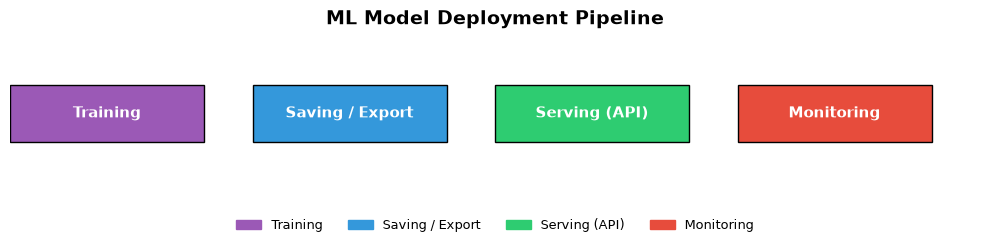

In [6]:
# WHAT: draw the four stages of the ML deployment pipeline as a simple timeline.
# WHY: keeping the big picture visible - train, export, serve, monitor - anchors every exercise below.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Each stage gets a bar segment, a color and a label.
stages = ['Training', 'Saving / Export', 'Serving (API)', 'Monitoring']
starts = [0, 2.5, 5, 7.5]
durations = [2, 2, 2, 2]
colors = ['#9b59b6', '#3498db', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(10, 3))
# Draw the horizontal bars and write each stage name inside its segment.
for i, (stage, start, dur, color) in enumerate(zip(stages, starts, durations, colors)):
    ax.barh(0, dur, left=start, height=0.5, color=color, edgecolor='black')
    ax.text(start + dur / 2, 0, stage, ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')

ax.set_xlim(0, 10)
ax.set_ylim(-0.6, 0.6)
ax.axis('off')
ax.set_title('ML Model Deployment Pipeline', fontsize=14, fontweight='bold', pad=15)

# Legend below the chart mapping colors to stages.
patches = [mpatches.Patch(color=c, label=s) for c, s in zip(colors, stages)]
ax.legend(handles=patches, loc='lower center', ncol=4, frameon=False,
          bbox_to_anchor=(0.5, -0.45), fontsize=9)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

## 🌍 Real-World Worked Example — Deploy a Trained Model as a REST API

**Industry context:**
- Spotify's recommendation model is served via a FastAPI microservice handling 400M users
- Instagram's image moderation runs as a containerised PyTorch model behind a REST endpoint
- Every ML feature in a modern app goes through a model serving layer like this

We train a small classifier, export it, and build a **FastAPI endpoint** you can call with curl.

In [7]:
# ── Part 1: Train and save a model ────────────────────────────────────────
import torch, torch.nn as nn
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

iris = load_iris()
X = StandardScaler().fit_transform(iris.data.astype(np.float32))
y = iris.target
X_tr,X_te,y_tr,y_te = train_test_split(X, y, test_size=0.2, random_state=42)

model = nn.Sequential(nn.Linear(4,32), nn.ReLU(), nn.Linear(32,3))
opt   = torch.optim.Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss()
Xt = torch.tensor(X_tr); Yt = torch.tensor(y_tr, dtype=torch.long)

for _ in range(200):
    loss = loss_fn(model(Xt), Yt)
    opt.zero_grad(); loss.backward(); opt.step()

torch.save(model.state_dict(), '/tmp/iris_model.pt')
print("Model saved to /tmp/iris_model.pt")

# Verify
model.eval()
with torch.no_grad():
    acc = (model(torch.tensor(X_te)).argmax(1)==torch.tensor(y_te)).float().mean()
print(f"Test accuracy: {acc:.2%}")

# ── Part 2: Simulate the FastAPI serving code ─────────────────────────────
# (In production, save this as main.py and run: uvicorn main:app --reload)
fastapi_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import torch, torch.nn as nn
import numpy as np

app = FastAPI(title="Iris Classifier API")

# Load model at startup
model = nn.Sequential(nn.Linear(4,32), nn.ReLU(), nn.Linear(32,3))
model.load_state_dict(torch.load("/tmp/iris_model.pt"))
model.eval()
CLASSES = ["setosa", "versicolor", "virginica"]

class IrisRequest(BaseModel):
    sepal_length: float
    sepal_width: float
    petal_length: float
    petal_width: float

@app.post("/predict")
def predict(req: IrisRequest):
    features = torch.tensor([[req.sepal_length, req.sepal_width,
                               req.petal_length, req.petal_width]])
    with torch.no_grad():
        logits = model(features)
        probs  = torch.softmax(logits, dim=1)[0]
        label  = CLASSES[probs.argmax().item()]
    return {"prediction": label, "confidence": round(probs.max().item(), 3)}

@app.get("/health")
def health(): return {"status": "ok"}

# Run with: uvicorn main:app --host 0.0.0.0 --port 8000
# Test with: curl -X POST http://localhost:8000/predict -H "Content-Type: application/json" \
#            -d '{"sepal_length":5.1,"sepal_width":3.5,"petal_length":1.4,"petal_width":0.2}'
'''
print("\n── FastAPI serving code (save as main.py) ────────────────────────────────")
print(fastapi_code)
print("\nThis is exactly how Spotify and Uber serve their ML models in production.")

Model saved to /tmp/iris_model.pt
Test accuracy: 90.00%

── FastAPI serving code (save as main.py) ────────────────────────────────

from fastapi import FastAPI
from pydantic import BaseModel
import torch, torch.nn as nn
import numpy as np

app = FastAPI(title="Iris Classifier API")

# Load model at startup
model = nn.Sequential(nn.Linear(4,32), nn.ReLU(), nn.Linear(32,3))
model.load_state_dict(torch.load("/tmp/iris_model.pt"))
model.eval()
CLASSES = ["setosa", "versicolor", "virginica"]

class IrisRequest(BaseModel):
    sepal_length: float
    sepal_width: float
    petal_length: float
    petal_width: float

@app.post("/predict")
def predict(req: IrisRequest):
    features = torch.tensor([[req.sepal_length, req.sepal_width,
                               req.petal_length, req.petal_width]])
    with torch.no_grad():
        logits = model(features)
        probs  = torch.softmax(logits, dim=1)[0]
        label  = CLASSES[probs.argmax().item()]
    return {"prediction": label, "confi

## 📝 Summary

In this notebook, you practiced:
- **Optimizing** deep learning models (quantization, pruning, ONNX export) to reduce size and improve inference speed
- **Serving** a model through a REST API using Flask or FastAPI
- **Containerizing** or packaging the model for repeatable deployment
- **Monitoring** deployed model performance (latency, error rate, accuracy drift)

**Next steps:** Explore cloud-based serving (AWS SageMaker, GCP Vertex AI) in Course 11 to scale these deployment patterns to production traffic.

## 📚 References & Further Reading

**Frameworks:**
- [FastAPI Documentation](https://fastapi.tiangolo.com/) — Modern Python API framework
- [ONNX Runtime](https://onnxruntime.ai/) — Cross-platform inference
- [BentoML](https://github.com/bentoml/BentoML) — ML model serving framework

**Cloud Services:**
- [AWS SageMaker Inference](https://docs.aws.amazon.com/sagemaker/latest/dg/deploy-model.html)
- [Google Cloud Vertex AI](https://cloud.google.com/vertex-ai/docs/predictions/overview)

**State-of-the-Art:** Uber, Airbnb, and Spotify deploy hundreds of ML models using microservices with FastAPI/gRPC.